# 03 — LSTM Time-Series Forecasting

> **Fixes:** country name validation, auto seq_len, empty-data guards, correct history access.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
print("Imports OK")


Imports OK


## 1. Load data — check country names

In [2]:
featured = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])
print(f"Shape    : {featured.shape}")
print(f"Columns  : {list(featured.columns)}")
all_countries = sorted(featured['country'].unique())
print(f"Total countries: {len(all_countries)}")
print()
print("Sample country names (first 40 with row counts):")
for c in all_countries[:40]:
    n = len(featured[featured['country'] == c])
    print(f"  '{c}'  ({n} rows)")


Shape    : (268982, 44)
Columns  : ['country', 'date', 'confirmed_cumulative', 'deaths_cumulative', 'new_tests_per_thousand', 'total_vaccinations_per_hundred', 'people_fully_vaccinated_per_hundred', 'stringency_index', 'population_density', 'median_age', 'hospital_beds_per_thousand', 'life_expectancy', 'population', 'mob_retail', 'mob_grocery', 'mob_transit', 'mob_work', 'mob_residential', 'new_cases', 'new_deaths', 'new_cases_7d', 'new_deaths_7d', 'new_cases_7d_lag7', 'new_cases_7d_lag14', 'new_cases_7d_lag21', 'new_cases_7d_rmean7', 'new_cases_7d_rstd7', 'new_cases_7d_rmax7', 'new_cases_7d_rmean14', 'new_cases_7d_rstd14', 'new_cases_7d_rmax14', 'new_cases_7d_rmean30', 'new_cases_7d_rstd30', 'new_cases_7d_rmax30', 'growth_rate', 'growth_accel', 'r0_estimate', 'cfr', 'day_of_week', 'month', 'week_of_year', 'days_since_start', 'mob_composite', 'vax_lag14']
Total countries: 201

Sample country names (first 40 with row counts):
  'Afghanistan'  (2008 rows)
  'Albania'  (1074 rows)
  'Alge

## 2. Select country

> Use the **exact** name printed in Cell 1. Most common fix: use `'US'` not `'United States'`.

In [3]:
from src.features import get_feature_columns

FEATURE_COLS = [c for c in get_feature_columns() if c in featured.columns]
TARGET       = 'new_cases_7d'

# ── SET YOUR COUNTRY HERE ──────────────────────────────────────────────────
COUNTRY = 'US'    # Use exact name printed in Cell 1 above
# ──────────────────────────────────────────────────────────────────────────

if COUNTRY not in featured['country'].values:
    close = [c for c in all_countries if COUNTRY.lower() in c.lower()]
    raise ValueError(
        f"Country '{COUNTRY}' not found.\n"
        f"Similar names: {close}\n"
        f"Run Cell 1 to see all valid names."
    )

cdf = (featured[featured['country'] == COUNTRY]
       .sort_values('date')
       .reset_index(drop=True))
cdf[FEATURE_COLS] = cdf[FEATURE_COLS].fillna(0)
cdf[TARGET]       = cdf[TARGET].fillna(0)

print(f"Country    : {COUNTRY}")
print(f"Total rows : {len(cdf)}")
print(f"Date range : {cdf['date'].min().date()} -> {cdf['date'].max().date()}")
print(f"Features   : {len(FEATURE_COLS)}")
print(f"Target col : {TARGET}")
print(f"Target stats: min={cdf[TARGET].min():.0f}  max={cdf[TARGET].max():.0f}  mean={cdf[TARGET].mean():.0f}")
if len(cdf) < 60:
    print(f"WARNING: Only {len(cdf)} rows — try COUNTRY = 'US'")
else:
    print(f"OK: {len(cdf)} rows available.")


Country    : US
Total rows : 1121
Date range : 2020-02-13 -> 2023-03-09
Features   : 21
Target col : new_cases_7d
Target stats: min=0  max=806963  mean=92503
OK: 1121 rows available.


## 3. Train / test split

In [5]:
TEST_DAYS = 30

cutoff = cdf['date'].max() - pd.Timedelta(days=TEST_DAYS)
train  = cdf[cdf['date'] <= cutoff].copy()
test   = cdf[cdf['date'] >  cutoff].copy()

if len(train) == 0 or len(test) == 0:
    print("WARNING: Date split produced empty sets — using 80/20 split.")
    idx   = max(1, int(len(cdf) * 0.8))
    train = cdf.iloc[:idx].copy()
    test  = cdf.iloc[idx:].copy()

X_train = train[FEATURE_COLS].values.astype('float32')
y_train = train[TARGET].values.astype('float32')
X_test  = test[FEATURE_COLS].values.astype('float32')
y_test  = test[TARGET].values.astype('float32')

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

if len(X_train) == 0:
    raise ValueError(
        f"Training set is EMPTY even after fallback.\n"
        f"Total rows for '{COUNTRY}': {len(cdf)}\n"
        f"Try COUNTRY = 'US'"
    )


Train : (1091, 21)
Test  : (30, 21)


## 4. Auto-select seq_len

In [6]:
def safe_seq_len(n_rows, candidates=(21, 14, 7, 5, 3)):
    for s in candidates:
        if n_rows > s + 20:
            return s
    return max(2, n_rows // 4)

SEQ_LEN = safe_seq_len(len(X_train))
print(f"Training rows   : {len(X_train)}")
print(f"Chosen seq_len  : {SEQ_LEN}")
print(f"Sequences built : {len(X_train) - SEQ_LEN}")


Training rows   : 1091
Chosen seq_len  : 21
Sequences built : 1070


## 5. Train LSTM

In [8]:
!pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   -------------------

In [9]:
from src.models.lstm_model import LSTMForecaster

model = LSTMForecaster(
    seq_len    = SEQ_LEN,
    units      = 64,
    dropout    = 0.2,
    epochs     = 50,
    batch_size = 32,
    patience   = 8,
)

model.fit(X_train, y_train, validation_split=0.1)
print("Training complete.")


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 8.9927 - val_loss: 4.8297 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.5134 - val_loss: 0.3811 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4307 - val_loss: 0.2166 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3018 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2100 - val_loss: 0.0721 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1690 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1294 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1071 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0803 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 10/50
31/31 ━

## 6. Training curves

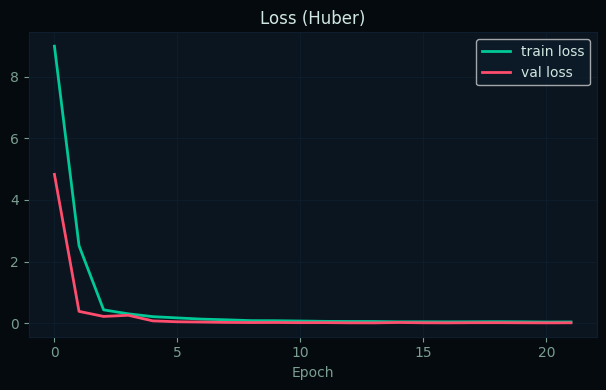

Saved: outputs/plots/lstm_training_curves.png


In [10]:
hist = model.model.history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#050a0f')
for ax in axes:
    ax.set_facecolor('#0a1520')
    for sp in ax.spines.values():
        sp.set_edgecolor('#0f1e2e')
    ax.grid(color='#0f2030', linewidth=0.5)
    ax.tick_params(colors='#7a9e90')

axes[0].plot(hist['loss'], color='#00c896', lw=2, label='train loss')
if 'val_loss' in hist:
    axes[0].plot(hist['val_loss'], color='#ff4d6d', lw=2, label='val loss')
axes[0].set_title('Loss (Huber)', color='#d0e8e0')
axes[0].set_xlabel('Epoch', color='#7a9e90')
axes[0].legend(facecolor='#0d1b2a', labelcolor='#d0e8e0')

if 'lr' in hist:
    axes[1].plot(hist['lr'], color='#ffb830', lw=2)
    axes[1].set_title('Learning Rate', color='#d0e8e0')
    axes[1].set_xlabel('Epoch', color='#7a9e90')
else:
    axes[1].set_visible(False)

plt.tight_layout()
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/plots/lstm_training_curves.png")


In [14]:
print(dir(model))


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_build', '_fit_scaler', '_scale', '_x_mean', '_x_std', 'batch_size', 'dropout', 'epochs', 'fit', 'load', 'model', 'patience', 'predict', 'save', 'seq_len', 'units']


## 7. Predict

In [15]:
preds = model.predict(X_test)

if len(preds) == 0:
    print(f"WARNING: No predictions generated.")
    print(f"Test rows: {len(X_test)}  |  seq_len used: {model._fitted_seq_len}")
    print("Increase TEST_DAYS or reduce SEQ_LEN")
else:
    offset = model.seq_len
    actual = y_test[offset : offset + len(preds)]
    dates  = test['date'].values[offset : offset + len(preds)]
    print(f"Predictions : {len(preds)}")
    print(f"Actual  range: min={actual.min():.0f}  max={actual.max():.0f}  mean={actual.mean():.0f}")
    print(f"Predict range: min={preds.min():.0f}  max={preds.max():.0f}  mean={preds.mean():.0f}")



Predictions : 9
Actual  range: min=30972  max=38612  mean=35092
Predict range: min=39590  max=42407  mean=40525


## 8. Evaluate

In [16]:
if len(preds) > 0:
    from src.evaluation import rmse, mae, mape
    r = rmse(actual, preds)
    m = mae(actual, preds)
    p = mape(actual, preds)
    print("=" * 42)
    print(f"  LSTM Evaluation --- {COUNTRY}")
    print("=" * 42)
    print(f"  RMSE : {r:>12.2f}")
    print(f"  MAE  : {m:>12.2f}")
    print(f"  MAPE : {p:>12.2f} %")
    print("=" * 42)


  LSTM Evaluation --- US
  RMSE :      6634.05
  MAE  :      5433.40
  MAPE :        16.53 %


## 9. Forecast plot

In [17]:
if len(preds) > 0:
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor('#050a0f')
    ax.set_facecolor('#0a1520')

    tail = cdf.tail(120)
    ax.plot(tail['date'], tail[TARGET],
            color='#ffffff', lw=1.2, alpha=0.45, label='Historical (7d avg)')
    ax.plot(dates, actual, color='#ffffff',  lw=1.8,            label='Actual (test)')
    ax.plot(dates, preds,  color='#00c896',  lw=2.2, ls='--',   label='LSTM forecast')
    ax.fill_between(dates,
                    np.maximum(0, preds * 0.85), preds * 1.15,
                    color='#00c896', alpha=0.1, label='+-15% band')

    ax.set_title(f'LSTM Forecast --- {COUNTRY}', color='#d0e8e0', fontsize=13)
    ax.set_xlabel('Date',                        color='#7a9e90')
    ax.set_ylabel('Daily New Cases (smoothed)',   color='#7a9e90')
    ax.tick_params(colors='#7a9e90', labelsize=9)
    for sp in ax.spines.values():
        sp.set_edgecolor('#0f1e2e')
    ax.grid(color='#0f2030', linewidth=0.5)
    ax.legend(facecolor='#0d1b2a', edgecolor='#1a3a2a', labelcolor='#d0e8e0', fontsize=9)

    plt.tight_layout()
    safe_name = COUNTRY.replace(' ', '_').replace('*', '').replace('/', '-')
    path = f'../outputs/plots/lstm_forecast_{safe_name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")


Saved: ../outputs/plots/lstm_forecast_US.png


C:\Users\Dell\AppData\Local\Temp\ipykernel_14696\2691937932.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 10. Save model

In [19]:
!pip install joblib


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)


In [20]:
os.makedirs('../models/saved', exist_ok=True)
safe_name = COUNTRY.replace(' ', '_').replace('*', '').replace('/', '-')
save_path = f'../models/saved/lstm_{safe_name}.keras'
model.save(save_path)
print(f"Model saved: {save_path}")


  LSTM saved → ../models/saved/lstm_US.keras
Model saved: ../models/saved/lstm_US.keras
